# Running a Parameter Sweep

This notebook demonstrates how to compute $T_c(d_F)$ curves for
**multiple ferromagnets** on the same plot, allowing direct comparison
of how exchange energy and coherence length affect the proximity effect.

## Setup

We compare four ferromagnets coupled to a 50 nm Nb layer:

| Material | $E_{\text{ex}}$ (meV) | $\xi_F$ (nm) | Character |
|----------|----------------------:|-------------:|----------|
| Fe       | 256                   | 0.7          | Strong: rapid oscillation |
| Co       | 300                   | 0.6          | Strong: fastest decay |
| Ni       | 150                   | 1.2          | Strong: slower than Fe |
| Py       | 80                    | 1.5          | Moderate: visible oscillation |

In [1]:
import sys
sys.path.insert(0, r"c:\Users\seans\Documents\GitHub\SUPERMag-Simulation-Suite\python")

import numpy as np
import matplotlib.pyplot as plt
import supermag

nb = supermag.get_material("Nb")
d_F = np.linspace(0.5, 30.0, 200)

print(f"Superconductor: Nb (Tc0 = {nb['Tc']} K, ξ_S = {nb['xi_S']} nm)")
print(f"d_F range: {d_F[0]} – {d_F[-1]} nm ({len(d_F)} points)")

Superconductor: Nb (Tc0 = 9.2 K, ξ_S = 38.0 nm)
d_F range: 0.5 – 30.0 nm (200 points)


## Multi-Material Sweep

Loop over ferromagnets and compute $T_c(d_F)$ for each.
The key physics to observe:

- **Stronger ferromagnets** (larger $E_{\text{ex}}$, smaller $\xi_F$) suppress
  $T_c$ more rapidly and oscillate on a shorter length scale
- **Weaker ferromagnets** show more gradual suppression but the oscillation
  period is longer, potentially allowing observation of the non-monotonic behavior

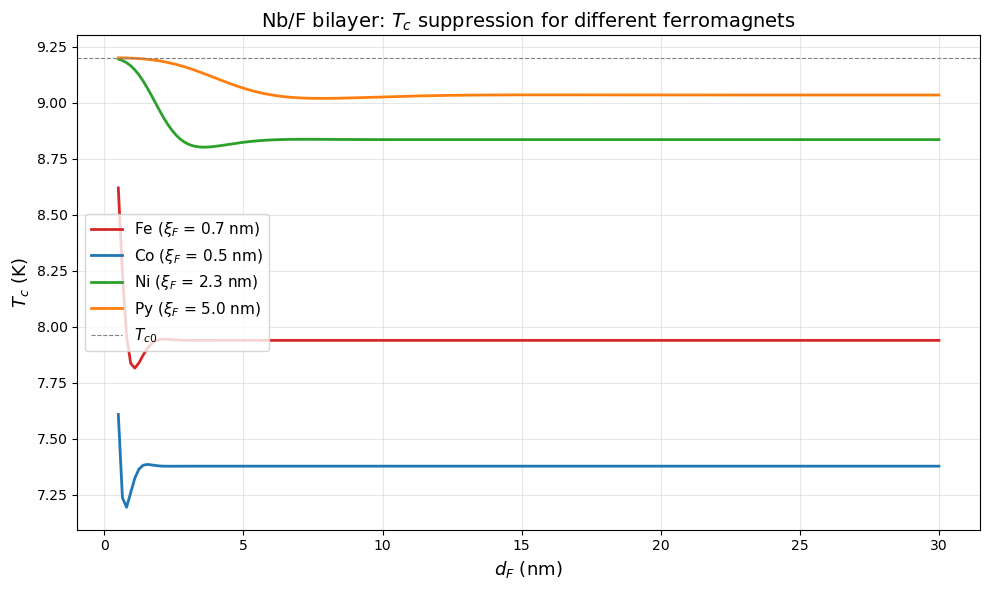

In [2]:
ferromagnets = ["Fe", "Co", "Ni", "Py"]
colors = ["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e"]

fig, ax = plt.subplots(figsize=(10, 6))

for fm_name, color in zip(ferromagnets, colors):
    fm = supermag.get_material(fm_name)
    Tc = supermag.critical_temperature(
        Tc0=nb["Tc"],
        d_S=50.0,
        d_F_array=d_F,
        E_ex=fm["E_ex"],
        xi_S=nb["xi_S"],
        xi_F=fm["xi_F"],
        gamma=0.15,
    )
    ax.plot(d_F, Tc, color=color, linewidth=2, label=f"{fm_name} ($\\xi_F$ = {fm['xi_F']} nm)")

ax.axhline(y=nb["Tc"], ls="--", color="gray", linewidth=0.8, label=r"$T_{c0}$")
ax.set_xlabel(r"$d_F$ (nm)", fontsize=13)
ax.set_ylabel(r"$T_c$ (K)", fontsize=13)
ax.set_title("Nb/F bilayer: $T_c$ suppression for different ferromagnets", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Thickness Sweep of the S Layer

We can also study how $T_c$ depends on the **superconductor** thickness $d_S$
at fixed $d_F$. Thinner S layers are more strongly affected by the proximity
effect.

The transparency parameter $\gamma = \xi_S / d_S$ controls the coupling
strength — larger $\gamma$ (thinner S) means stronger suppression.

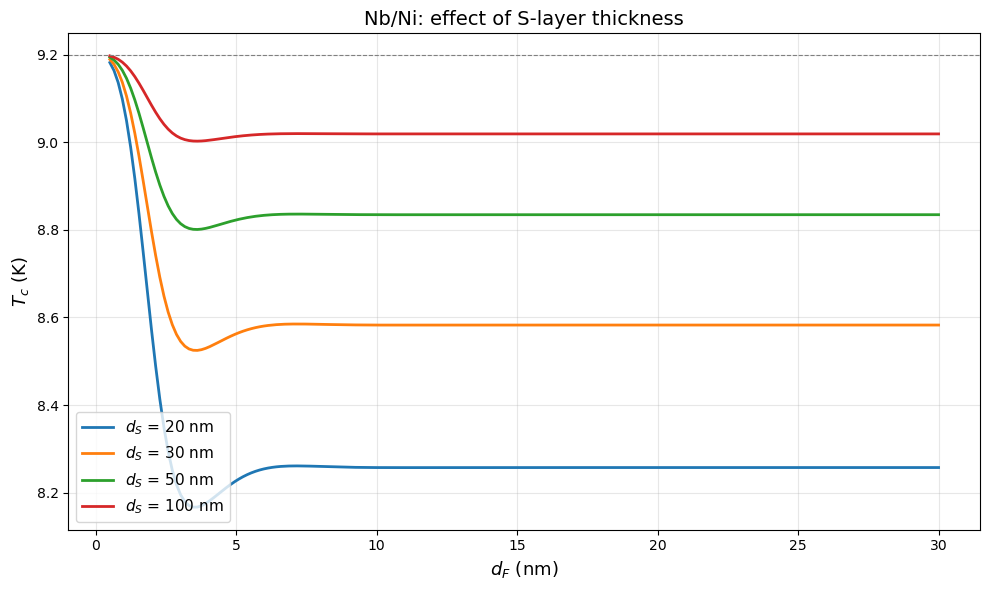

In [3]:
ni = supermag.get_material("Ni")
d_S_values = [20, 30, 50, 100]  # nm

fig, ax = plt.subplots(figsize=(10, 6))

for d_S in d_S_values:
    Tc = supermag.critical_temperature(
        Tc0=nb["Tc"],
        d_S=d_S,
        d_F_array=d_F,
        E_ex=ni["E_ex"],
        xi_S=nb["xi_S"],
        xi_F=ni["xi_F"],
        gamma=0.15,
    )
    ax.plot(d_F, Tc, linewidth=2, label=f"$d_S$ = {d_S} nm")

ax.axhline(nb["Tc"], ls="--", color="gray", linewidth=0.8)
ax.set_xlabel(r"$d_F$ (nm)", fontsize=13)
ax.set_ylabel(r"$T_c$ (K)", fontsize=13)
ax.set_title("Nb/Ni: effect of S-layer thickness", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Model Comparison: Thin-S vs. Fominov

SUPERMag implements two models for $T_c$ determination:

| Model | Applicable when | Key approximation |
|-------|----------------|-------------------|
| `thin_s` | $d_S \ll \xi_S$ | Order parameter uniform across S |
| `fominov` | Arbitrary $d_S$ | Includes boundary resistance $\gamma_B$ |

Let's compare them for a weak ferromagnet where the difference is visible.

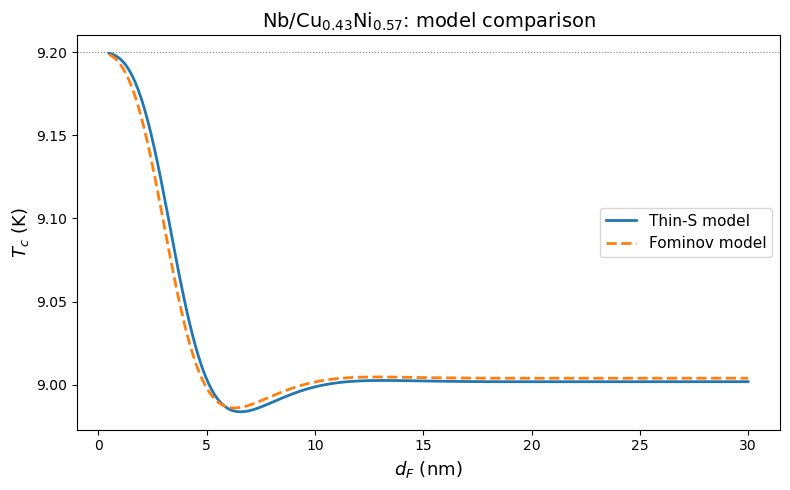

In [4]:
cuni = supermag.get_material("Cu0.43Ni0.57")

fig, ax = plt.subplots(figsize=(8, 5))

for model, ls, label in [("thin_s", "-", "Thin-S model"),
                          ("fominov", "--", "Fominov model")]:
    Tc = supermag.critical_temperature(
        Tc0=nb["Tc"],
        d_S=50.0,
        d_F_array=d_F,
        E_ex=cuni["E_ex"],
        xi_S=nb["xi_S"],
        xi_F=cuni["xi_F"],
        gamma=0.15,
        gamma_B=0.3,
        model=model,
    )
    ax.plot(d_F, Tc, ls=ls, linewidth=2, label=label)

ax.axhline(nb["Tc"], ls=":", color="gray", linewidth=0.8)
ax.set_xlabel(r"$d_F$ (nm)", fontsize=13)
ax.set_ylabel(r"$T_c$ (K)", fontsize=13)
ax.set_title(r"Nb/Cu$_{0.43}$Ni$_{0.57}$: model comparison", fontsize=14)
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()

## Saving Results

Export data as CSV for further analysis or publication-quality plotting.

In [5]:
# Example: save one curve
Tc_final = supermag.critical_temperature(
    Tc0=nb["Tc"], d_S=50.0, d_F_array=d_F,
    E_ex=ni["E_ex"], xi_S=nb["xi_S"], xi_F=ni["xi_F"],
    gamma=0.15,
)

data = np.column_stack([d_F, Tc_final])
# np.savetxt("nb_ni_tc_vs_df.csv", data, delimiter=",",
#            header="d_F_nm,Tc_K", comments="")
print(f"Data shape: {data.shape}")
print(f"First 5 rows:")
print(data[:5])

Data shape: (200, 2)
First 5 rows:
[[0.5        9.19419179]
 [0.64824121 9.18782841]
 [0.79648241 9.17806532]
 [0.94472362 9.16432373]
 [1.09296482 9.14620784]]
